In [19]:
import yaml
import pypsa
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [20]:
with open(Path.cwd().parent / 'config' / 'plotting.default.yaml', 'r') as f:
    tech_colors = yaml.safe_load(f)['plotting']['tech_colors']
tech_colors['rural ground heat pump'] = tech_colors['ground heat pump']
tech_colors['rural biomass boiler'] = tech_colors['biomass boiler']
tech_colors['urban central air heat pump'] = tech_colors['air heat pump']
tech_colors['urban central gas boiler'] = tech_colors['gas boiler']
tech_colors['urban central gas CHP'] = tech_colors['gas CHP']
tech_colors['urban central solid biomass CHP'] = tech_colors['biomass CHP']
tech_colors['urban decentral air heat pump'] = tech_colors['air heat pump']
tech_colors['urban decentral gas boiler'] = tech_colors['gas boiler']
tech_colors['urban decentral biomass boiler'] = tech_colors['biomass boiler']

In [21]:
configfile = Path.cwd().parent / 'config.basicrun.yaml'
with open(configfile, 'r') as f:
    cost_year = yaml.safe_load(f)['costs']['year']
costs = pd.read_csv(
    Path.cwd().parent.parent / 'technology-data' / 'outputs' / f'costs_{cost_year}.csv', index_col=[0,1]
)

In [22]:
idx = pd.IndexSlice
lifetimes = costs.loc[idx[:, 'lifetime'], 'value']
lifetimes.index = lifetimes.index.droplevel(1)

discount_rates = costs.loc[idx[:, 'discount rate'], 'value']
discount_rates.index = discount_rates.index.droplevel(1)

def get_annuity_factor(lifetime, discount_rate):
    if isinstance(discount_rate, (int, float)) and discount_rate == 0:
        return 1 / lifetime
    return discount_rate / (1 - (1 + discount_rate) ** (-lifetime))

In [23]:
# steel-related stuff from index 170ish onwards in costs.loc[idx[:, 'lifetime'], :]
tech_costs_mapper = {
    'urban decentral air heat pump': 'decentral air-sourced heat pump',
    'urban decentral gas boiler': 'decentral gas boiler',
    'rural ground heat pump': 'decentral ground-sourced heat pump',
    'Combined-Cycle Gas': 'CCGT',
    'Open-Cycle Gas': 'OCGT',
    'rural biomass boiler': 'biomass boiler',
    'urban central biomass CHP': 'biomass CHP',
    'urban central air heat pump': 'central air-sourced heat pump',
    'urban central gas CHP': 'central gas CHP',
    'urban central gas boiler': 'central gas boiler',
    'heat<100 industry industrial heat pump medium temperature': 'industrial heat pump medium temperature',
    'heat100-200 industry industrial heat pump high temperature': 'industrial heat pump high temperature',
    'heat100-200 industry electric boiler steam': 'electric boiler steam',
    'heat100-200 industry gas': 'gas boiler steam',
    'heat100-200 industry solid biomass': 'solid biomass boiler steam',
    # 'heat200-500 industry hydrogen': 'hydrogen',
    # 'heat>500 industry hydrogen': 'hydrogen',
    'Onshore Wind': 'onwind',
    'Offshore Wind (AC)': 'offwind',
    'Solar': 'solar',
    'Reservoir & Dam': 'ror',
    'nuclear': 'nuclear',
}
carrier_network_names = {
    'Combined-Cycle Gas': 'CCGT',
    'Open-Cycle Gas': 'OCGT',
    'Onshore Wind': 'onwind',
    'Offshore Wind (AC)': 'offwind-ac',
    'Solar': 'solar',
    'Reservoir & Dam': 'ror',
    'nuclear': 'nuclear',
}

In [24]:
filename = 'base_s_50__3H-T-H-B-I-A-dist1_2035_free_2000.nc'
n = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / filename
)
clusters = int(filename[7:].split('_')[0])

INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_free_2000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [25]:
n.loads.carrier.unique()

array(['electricity', 'land transport EV', 'land transport oil',
       'urban central heat', 'heat<100 industry', 'heat100-200 industry',
       'heat200-500 industry', 'heat>500 industry',
       'solid biomass for industry', 'steel', 'gas for industry',
       'H2 for industry', 'industry methanol', 'naphtha for industry',
       'industry electricity', 'process emissions', 'NH3',
       'coal for industry', 'shipping methanol', 'shipping oil',
       'kerosene for aviation', 'agriculture electricity',
       'agriculture heat', 'agriculture machinery electric',
       'agriculture machinery oil', 'rural heat', 'urban decentral heat'],
      dtype=object)

In [26]:
print(n.links.carrier.unique())
print(n.generators.carrier.unique())

['DC' 'co2 sequestered' 'OCGT' 'CCGT' 'H2 Electrolysis' 'gas pipeline'
 'gas pipeline new' 'battery charger' 'battery discharger' 'Sabatier'
 'SMR' 'BEV charger' 'V2G' 'oil refining' 'land transport oil'
 'urban central air heat pump' 'urban central gas boiler'
 'urban central gas CHP' 'unsustainable bioliquids' 'biogas to gas'
 'urban central solid biomass CHP' 'urban central solid biomass CHP CC'
 'biomass to liquid' 'electrobiofuels' 'Haber-Bosch' 'ammonia cracker'
 'biomass-to-methanol' 'OCGT methanol' 'heat<100 industry solid biomass'
 'heat<100 industry gas'
 'heat<100 industry industrial heat pump medium temperature'
 'heat<100 industry electric boiler steam'
 'heat100-200 industry solid biomass' 'heat100-200 industry gas'
 'heat100-200 industry industrial heat pump high temperature'
 'heat100-200 industry electric boiler steam'
 'heat200-500 industry solid biomass' 'heat200-500 industry gas'
 'heat200-500 industry hydrogen' 'heat>500 industry gas'
 'heat>500 industry hydrogen' 

In [27]:
ccc = pd.Index(n.links.carrier.unique())
ccc[ccc.str.contains('urban central')]

Index(['urban central air heat pump', 'urban central gas boiler',
       'urban central gas CHP', 'urban central solid biomass CHP',
       'urban central solid biomass CHP CC'],
      dtype='object')

In [28]:
# Find all links that connect to rural heat buses
rural_heat_buses = n.buses[n.buses.carrier == 'rural heat'].index
rural_heat_links = n.links[n.links.bus1.isin(rural_heat_buses)]
rural_heat_link_carriers = rural_heat_links.carrier.unique()
print("Carriers of links leading to rural heat buses:")
print(rural_heat_link_carriers)


Carriers of links leading to rural heat buses:
['rural air heat pump' 'rural biomass boiler' 'rural gas boiler'
 'rural ground heat pump']


In [29]:
shown_techs = {
    # 'AC': ['Combined-Cycle Gas', 'Open-Cycle Gas', 'Onshore Wind', 'Offshore Wind (AC)', 'nuclear', 'Reservoir & Dam', 'Solar'],
    'AC': ['Combined-Cycle Gas', 'Open-Cycle Gas', 'Onshore Wind', 'Offshore Wind (AC)', 'nuclear', 'Solar'],
    'rural heat': ['rural gas boiler', 'rural ground heat pump', 'rural biomass boiler'],
    'urban decentral heat': ['urban decentral gas boiler', 'urban decentral air heat pump', 'urban decentral biomass boiler'],
    # 'urban central heat': ['urban central gas boiler', 'urban central air heat pump', 'urban central gas CHP', 'urban central solid biomass CHP']
    'urban central heat': ['urban central gas boiler', 'urban central air heat pump', 'urban central solid biomass CHP'],
    'heat<100 industry': [
        'heat<100 industry solid biomass',
        'heat<100 industry gas',
        'heat<100 industry industrial heat pump medium temperature',
        'heat<100 industry electric boiler steam',
    ],
    'heat100-200 industry': [
        'heat100-200 industry solid biomass',
        'heat100-200 industry gas',
        'heat100-200 industry industrial heat pump high temperature',
        'heat100-200 industry electric boiler steam',
    ],
    'heat200-500 industry': [
        'heat200-500 industry solid biomass',
        'heat200-500 industry gas',
        'heat200-500 industry hydrogen',
    ],
    'heat>500 industry': [
        'heat>500 industry gas',
        'heat>500 industry hydrogen',
    ],
    'steel': [
        'gas DRI',
        'H2 DRI',
        'BOF',
    ],
}
fuels = {
    'Combined-Cycle Gas': 'gas',
    'Open-Cycle Gas': 'gas',
    'rural gas boiler': 'gas',
    'rural biomass boiler': 'solid biomass',
    'rural ground heat pump': 'AC',
    'urban decentral gas boiler': 'gas',
    'urban decentral air heat pump': 'AC',
    'urban decentral biomass boiler': 'solid biomass',
    'urban central gas boiler': 'gas',
    'urban central air heat pump': 'AC',
    'urban central gas CHP': 'gas',
    'urban central solid biomass CHP': 'solid biomass',
    'heat<100 industry solid biomass': 'solid biomass',
    'heat<100 industry gas': 'gas',
    'heat<100 industry industrial heat pump medium temperature': 'AC',
    'heat<100 industry electric boiler steam': 'AC',
    'heat100-200 industry solid biomass': 'solid biomass',
    'heat100-200 industry gas': 'gas',
    'heat100-200 industry industrial heat pump high temperature': 'AC',
    'heat100-200 industry electric boiler steam': 'AC',
    'heat200-500 industry solid biomass': 'solid biomass',
    'heat200-500 industry gas': 'gas',
    'heat200-500 industry hydrogen': 'H2',
    'heat>500 industry gas': 'gas',
    'heat>500 industry hydrogen': 'H2',
}
fixed_carriers = ['gas', 'solid biomass']
endogenous_carriers = ['AC', 'H2']

In [30]:
nodal_capex = n.statistics.capex(groupby=['bus', 'carrier'])
nodal_opex = n.statistics.opex(groupby=['bus', 'carrier'])

nodal_caps = n.statistics.optimal_capacity(groupby=['bus', 'carrier'])
nodal_supply = n.statistics.supply(groupby=['bus', 'carrier'])
wth = n.statistics.withdrawal(groupby=['bus', 'carrier'])

In [31]:
def get_buses(buses):
    buses = pd.Index(buses)
    return buses.str.split().str[:2].str.join(' ')

def get_suffix(buses):
    buses = pd.Index(buses)
    return buses.str.split().str[2:].str.join(' ')[0]

get_suffix(
    n.buses.index[n.buses.carrier == 'H2']
)

'H2'

In [32]:
def get_marginal_cost(n, components):

    if not isinstance(components, pd.Index):
        components = pd.Index([components])

    if len(n.links.index.intersection(components)) > 0:
        return n.links.marginal_cost.loc[components]
    elif len(n.generators.index.intersection(components)) > 0:
        return n.generators.marginal_cost.loc[components]
    else:
        raise ValueError(f"No marginal cost found for {components}")


def get_fuel_cost(n, buses, carrier):

    if carrier in fixed_carriers:
        return n.generators.loc[n.generators.carrier == carrier, 'marginal_cost'].mean()

    elif carrier in endogenous_carriers:

        suffix = get_suffix(n.buses.index[n.buses.carrier == carrier])

        load = n.statistics.withdrawal(
            groupby="bus",
            aggregate_time=False,
            bus_carrier=carrier,
            aggregate_across_components=True,
        ).T[buses + ' '*bool(len(suffix)) + suffix]

        if not load.empty and load.sum().sum() > 0:
            price = n.buses_t.marginal_price.loc[:, load.columns]
            price = price.reindex(columns=load.columns, fill_value=1)

            weights = n.snapshot_weightings.generators
            a = weights @ (load * price)
            b = weights @ load
            fuel_cost = (a / b)

            fuel_cost.index = buses

            return fuel_cost

# get_fuel_cost(
#     n,
#     n.buses.index[n.buses.carrier == 'AC'][:3],
#     'H2'
# )

In [33]:
ss = nodal_opex.loc[idx[:, :, 'urban decentral gas boiler']]
print(ss.head())
ss.index = ss.index.droplevel(0)
ss.index = get_buses(ss.index)
ss.head()

component  bus      
Link       AL0 0 gas      1545.78618
           AT0 0 gas     80385.99145
           BA0 0 gas      6798.88313
           BE0 0 gas    250471.69504
           BG0 0 gas      4580.96470
dtype: float64


bus
AL0 0      1545.78618
AT0 0     80385.99145
BA0 0      6798.88313
BE0 0    250471.69504
BG0 0      4580.96470
dtype: float64

In [34]:
nice_names = {
    'nuclear': 'Nuclear',
    'rural gas boiler': 'Rural Gas Boiler',
    'rural ground heat pump': 'Rural Ground HP',
    'rural biomass boiler': 'Rural Biomass Boiler',
    'urban decentral gas boiler': 'Urban Decentral Gas Boiler',
    'urban decentral air heat pump': 'Urban Decentral Air HP',
    'urban decentral biomass boiler': 'Urban Decentral Biomass Boiler',
    'urban central gas boiler': 'Urban Central Gas Boiler',
    'urban central air heat pump': 'Urban Central Air HP',
    'urban central solid biomass CHP': 'Urban Central Biomass CHP',
    'heat<100 industry solid biomass': 'Heat<100 Biomass',
    'heat<100 industry gas': 'Heat<100 Gas',
    'heat<100 industry industrial heat pump medium temperature': 'Heat<100 HP',
    'heat<100 industry electric boiler steam': 'Heat<100 Electric Boiler',
    'heat100-200 industry solid biomass': 'Heat100-200 Biomass',
    'heat100-200 industry gas': 'Heat100-200 Gas',
    'heat100-200 industry industrial heat pump high temperature': 'Heat100-200 HP',
    'heat100-200 industry electric boiler steam': 'Heat100-200 Electric Boiler',
    'heat200-500 industry solid biomass': 'Heat200-500 Biomass',
    'heat200-500 industry gas': 'Heat200-500 Gas',
    'heat200-500 industry hydrogen': 'Heat200-500 Hydrogen',
    'heat>500 industry gas': 'Heat>500 Gas',
    'heat>500 industry hydrogen': 'Heat>500 Hydrogen',
    'gas DRI': 'gas DRI + EAF [MWh -> tSteel]',
    'H2 DRI': 'H2 DRI + EAF [MWh -> tSteel]',
    'BOF': 'BOF [MWh -> tSteel]'
}

In [35]:
gas_dri_gas_input = costs.loc[('natural gas direct iron reduction furnace', 'gas-input'), 'value'] # in MWh/t
gas_dri_ore_input = costs.loc[('natural gas direct iron reduction furnace', 'ore-input'), 'value'] # in MWh/t

h2_dri_electricity_input = costs.loc[('hydrogen direct iron reduction furnace', 'electricity-input'), 'value'] # in MWh/t
h2_dri_hydrogen_input = costs.loc[('hydrogen direct iron reduction furnace', 'hydrogen-input'), 'value'] # in MWh/t
h2_dri_ore_input = costs.loc[('hydrogen direct iron reduction furnace', 'ore-input'), 'value'] # in MWh/t

eaf_electricity_input = costs.loc[('electric arc furnace', 'electricity-input'), 'value'] # in MWh/t

bof_coal_input = costs.loc[('blast furnace-basic oxygen furnace', 'coal-input'), 'value'] # in MWh/t

steel_cc = {
    'gas DRI': 
        costs.loc[('natural gas direct iron reduction furnace', 'investment'), 'value'] +
        costs.loc[('electric arc furnace', 'investment'), 'value'],

    'H2 DRI': 
        costs.loc[('hydrogen direct iron reduction furnace', 'investment'), 'value'] +
        costs.loc[('electric arc furnace', 'investment'), 'value'],
    
    'BOF': 
        costs.loc[('blast furnace-basic oxygen furnace', 'investment'), 'value'],
}

def get_steel_vom(n, mode):

    assert mode in ['gas DRI', 'H2 DRI', 'BOF']

    gas_price = n.generators.loc[n.generators.carrier == 'gas', 'marginal_cost'].mean()
    coal_price = n.generators.loc[n.generators.carrier == 'coal', 'marginal_cost'].mean()

    ac_buses = n.buses.index[n.buses.carrier == 'AC']
    elec_price = n.buses_t.marginal_price.loc[:, ac_buses].mean()

    h2_buses = n.buses.index[n.buses.carrier == 'H2']
    h2_price = n.buses_t.marginal_price.loc[:, h2_buses].mean()
    h2_price.index = get_buses(h2_price.index)

    if mode == 'gas DRI':
        return gas_price * gas_dri_gas_input + elec_price * eaf_electricity_input
    elif mode == 'H2 DRI':
        return h2_price * h2_dri_hydrogen_input + elec_price * (h2_dri_electricity_input + eaf_electricity_input)
    elif mode == 'BOF':
        return coal_price * bof_coal_input

--------------------------------
Combined-Cycle Gas CCGT
--------------------------------
Open-Cycle Gas OCGT
--------------------------------
Onshore Wind onwind
--------------------------------
Offshore Wind (AC) offwind-ac
--------------------------------
nuclear nuclear
--------------------------------
Solar solar
--------------------------------
rural gas boiler rural gas boiler
--------------------------------
rural ground heat pump rural ground heat pump


--------------------------------
rural biomass boiler rural biomass boiler
--------------------------------
urban decentral gas boiler urban decentral gas boiler
--------------------------------
urban decentral air heat pump urban decentral air heat pump
--------------------------------
urban decentral biomass boiler urban decentral biomass boiler
--------------------------------
urban central gas boiler urban central gas boiler
--------------------------------
urban central air heat pump urban central air heat pump
--------------------------------
urban central solid biomass CHP urban central solid biomass CHP
--------------------------------
heat<100 industry solid biomass heat<100 industry solid biomass
--------------------------------
heat<100 industry gas heat<100 industry gas
--------------------------------
heat<100 industry industrial heat pump medium temperature heat<100 industry industrial heat pump medium temperature
--------------------------------
heat<100 industry electri

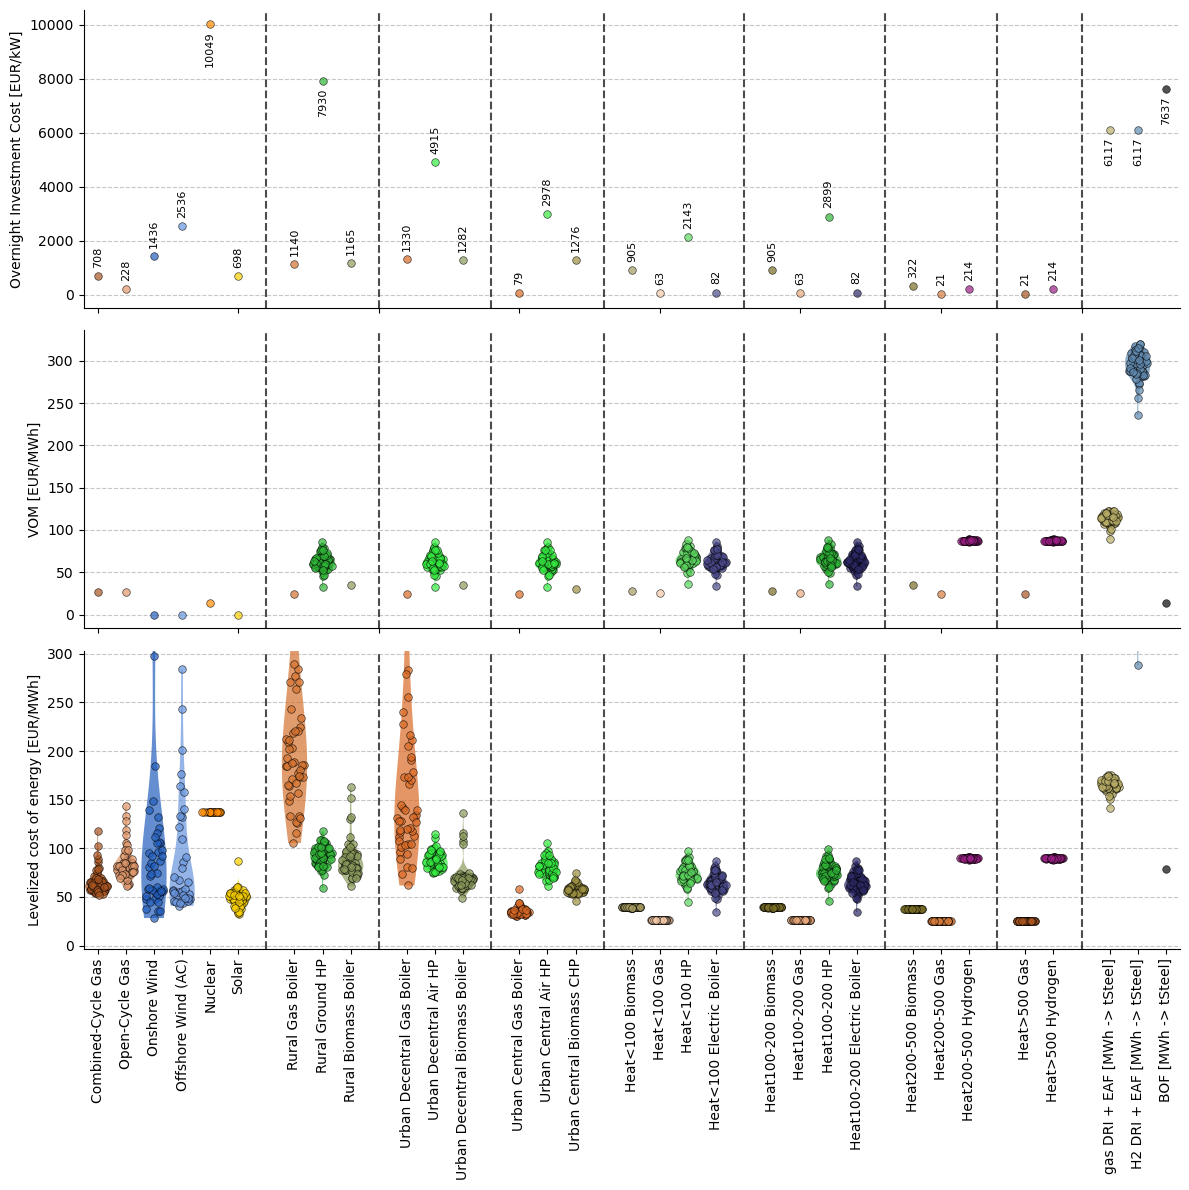

In [37]:
import seaborn as sns

idx = pd.IndexSlice

fig, axs = plt.subplots(3, 1, figsize=(12, 12))

axs[0].set_ylabel('Overnight Investment Cost [EUR/kW]')
axs[1].set_ylabel('VOM [EUR/MWh]')
axs[2].set_ylabel('Levelized cost of energy [EUR/MWh]')

xticklocs = list()
xticklabels = list()

inter_load_gap = 1
xloc_tracker = 0

scatter_kwargs = {
    's': 30,
    'edgecolor': 'black',
    'linewidth': 0.5,
    'alpha': 0.7,
}

all_locations = n.buses.index[n.buses.carrier == 'AC']

for load, carriers in shown_techs.items():

    for carrier in carriers:

        if load != 'steel':

            carrier_n = carrier_network_names.get(carrier, carrier)

            if carrier_n in n.links.carrier.unique():
                assets = n.links.index[n.links.carrier == carrier_n]
                asset_type = 'link'
            elif carrier_n in n.generators.carrier.unique():
                assets = n.generators.index[n.generators.carrier == carrier_n]
                asset_type = 'generator'
            else:
                raise ValueError(f"No assets found for {carrier_n}")

            print('--------------------------------')
            print(carrier, carrier_n)

            if asset_type == 'generator':
                capital_cost = n.generators.loc[assets, 'capital_cost'].mean()
            elif asset_type == 'link':
                capital_cost = n.links.loc[assets, 'capital_cost'].mean()

            costs_carrier_name = tech_costs_mapper.get(carrier, carrier)
            if costs_carrier_name in lifetimes.index:
                lt = lifetimes.loc[costs_carrier_name]
            else:
                lt = 25 # generic lifetime

            if costs_carrier_name in discount_rates.index:
                dr = discount_rates.loc[costs_carrier_name]
            else:
                dr = 0.07 # generic discount rate

            annuity_factor = get_annuity_factor(lt, dr)
            overnight = capital_cost / annuity_factor # uncompute annuitisation
        
        elif load == 'steel':

            overnight = steel_cc[carrier]


        axs[0].scatter(
            [xloc_tracker],
            [overnight / 1e3],
            color=tech_colors[carrier],
            **scatter_kwargs,
        )
        
        # Add vertical text label with cost value
        cost_value = overnight / 1e3
        if cost_value < 6000:
            va = 'bottom'
            y_offset = cost_value + 300  # slightly above
        else:
            va = 'top'
            y_offset = cost_value - 300  # slightly below
        
        axs[0].text(
            xloc_tracker,
            y_offset,
            f'{cost_value:.0f}',
            rotation=90,
            va=va,
            ha='center',
            fontsize=8,
            color='black'
        )

        if load != 'steel':
            marginal_cost = get_marginal_cost(n, assets)
            locations = get_buses(marginal_cost.index)
            avg_marginal_cost = marginal_cost.mean()

            # print(nodal_supply.loc[idx[:, :, carrier]])
            supply = nodal_supply.loc[idx[:, :, carrier]]
            supply.index = supply.index.droplevel(0)
            supply.index = get_buses(supply.index)

            built = nodal_caps.loc[idx[:, :, carrier]]
            built.index = built.index.droplevel(0)
            built.index = get_buses(built.index)

            if 'CHP' in carrier:
                supply = supply.iloc[1::2]

            locations = locations.intersection(all_locations)
            supply = supply.loc[supply.index.intersection(all_locations)]
            built = built.loc[built.index.intersection(all_locations)]

            assert (supply.index == locations).all()
            assert (built.index == locations).all()

            if carrier in fuels:
                fuel_carrier = fuels[carrier]
                fuel_cost = get_fuel_cost(n, locations, fuel_carrier)

            else:
                fuel_cost = 0

            vom = avg_marginal_cost + fuel_cost
        

        elif load == 'steel':
            vom = get_steel_vom(n, carrier)


        from typing import Iterable
        from scipy import stats
        
        def get_density_based_jitter(values, max_jitter=0.35):
            """Calculate jitter based on local probability density."""
            if len(values) < 2:
                return np.zeros_like(values)
            
            # Estimate KDE for the data
            kde = stats.gaussian_kde(values)
            densities = kde(values)
            
            # Normalize densities to [0, 1]
            densities_norm = (densities - densities.min()) / (densities.max() - densities.min() + 1e-10)
            
            # Higher density -> larger jitter range
            jitter_ranges = densities_norm * max_jitter
            
            # Generate random jitter proportional to local density
            jitter = np.array([np.random.uniform(-jr, jr) for jr in jitter_ranges])
            
            return jitter
        
        if isinstance(vom, Iterable):
            parts = axs[1].violinplot(
                [vom],
                positions=[xloc_tracker],
                widths=0.9,
                showmeans=False,
                showmedians=False,
                showextrema=False,
            )
            for pc in parts['bodies']:
                pc.set_facecolor(tech_colors[carrier])
                pc.set_alpha(0.7)
                pc.set_edgecolor('none')

            # Spread points along x-axis based on local density
            jitter = get_density_based_jitter(vom)
            axs[1].scatter(
                np.ones_like(vom) * xloc_tracker + jitter,
                vom,
                color=tech_colors[carrier],
                **scatter_kwargs,
            )
        else:
            axs[1].scatter(
                np.ones_like(vom) * xloc_tracker,
                vom,
                color=tech_colors[carrier],
                **scatter_kwargs,
            )

        if load != 'steel':
            lcoe = (capital_cost * built + (avg_marginal_cost + fuel_cost) * supply) / supply
        elif load == 'steel':
            annuity_factor = get_annuity_factor(40, 0.07)
            lcoe = (overnight * annuity_factor + vom * 8760) / 8760

        if isinstance(lcoe, Iterable):
            parts = axs[2].violinplot(
                [lcoe],
                positions=[xloc_tracker],
                widths=0.9,
                showmeans=False,
                showmedians=False,
                showextrema=False,
            )
            for pc in parts['bodies']:
                pc.set_facecolor(tech_colors[carrier])
                pc.set_alpha(0.7)
                pc.set_edgecolor('none')

            # Spread points along x-axis based on local density
            jitter = get_density_based_jitter(lcoe)
        else:
            jitter = 0

        axs[2].scatter(
            np.ones_like(lcoe) * xloc_tracker + jitter,
            lcoe,
            color=tech_colors[carrier],
            **scatter_kwargs,
        )

        xticklocs.append(xloc_tracker)
        xticklabels.append(nice_names.get(carrier, carrier))
        xloc_tracker += 1

    for ax in axs:
        ax.axvline(xloc_tracker + inter_load_gap / 2 - 0.5, color='black', linestyle='--', alpha=0.7)

    xloc_tracker += inter_load_gap


axs[-1].set_xticks(xticklocs)
axs[-1].set_xticklabels(xticklabels, rotation=90)

axs[0].set_xticklabels([])
axs[1].set_xticklabels([])

for ax in axs:
    ax.set_xlim(-0.5, xloc_tracker - 0.5 - inter_load_gap)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axs[-1].set_ylim(-3, 303)

plt.tight_layout()
plt.show()